### Data Loading

In [3]:
import pandas as pd

df = pd.read_csv("./dataset/synthetic_logs.csv")
df.head()

,timestamp,source,log_message,target_label,complexity
0,2025-06-27 07:20:25,ModernCRM,nova.osapi_compute.wsgi.server [req-b9718cd8-f...,HTTP Status,bert
1,1/14/2025 23:07,ModernCRM,Email service experiencing issues with sending,Critical Error,bert
2,1/17/2025 1:29,AnalyticsEngine,Unauthorized access to data was attempted,Security Alert,bert
3,2025-07-12 00:24:16,ModernHR,nova.osapi_compute.wsgi.server [req-4895c258-b...,HTTP Status,bert
4,2025-06-02 18:25:23,BillingSystem,nova.osapi_compute.wsgi.server [req-ee8bc8ba-9...,HTTP Status,bert


In [6]:
df.isnull().sum()

timestamp       0
source          0
log_message     0
target_label    0
complexity      0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   timestamp     2410 non-null   str  
 1   source        2410 non-null   str  
 2   log_message   2410 non-null   str  
 3   target_label  2410 non-null   str  
 4   complexity    2410 non-null   str  
dtypes: str(5)
memory usage: 94.3 KB


In [8]:
# source unique values
df.source.unique()

<StringArray>
[      'ModernCRM', 'AnalyticsEngine',        'ModernHR',   'BillingSystem',
   'ThirdPartyAPI',       'LegacyCRM']
Length: 6, dtype: str

In [9]:
# tareget_label unique values
df.target_label.unique()

<StringArray>
[        'HTTP Status',      'Critical Error',      'Security Alert',
               'Error', 'System Notification',      'Resource Usage',
         'User Action',      'Workflow Error', 'Deprecation Warning']
Length: 9, dtype: str

In [10]:
# Check some samples
df[df.target_label=='System Notification'].sample(10)

,timestamp,source,log_message,target_label,complexity
1928,4/20/2025 13:46,ModernCRM,Backup completed successfully.,System Notification,regex
1636,1/16/2025 12:56,AnalyticsEngine,System updated to version 5.1.0.,System Notification,regex
2036,6/11/2025 2:53,ModernHR,System updated to version 2.4.9.,System Notification,regex
2150,12/18/2025 1:21,ModernHR,Backup started at 2025-01-25 22:10:08.,System Notification,regex
535,3/16/2025 9:05,ThirdPartyAPI,Backup ended at 2025-07-01 14:07:11.,System Notification,regex
1921,11/21/2025 4:16,AnalyticsEngine,System updated to version 1.5.7.,System Notification,regex
1963,10/20/2025 14:55,AnalyticsEngine,Backup completed successfully.,System Notification,regex
1910,6/8/2025 13:52,ThirdPartyAPI,File data_6245.csv uploaded successfully by us...,System Notification,regex
151,7/12/2025 13:01,ThirdPartyAPI,Backup completed successfully.,System Notification,regex
2110,4/23/2025 17:22,AnalyticsEngine,File data_9075.csv uploaded successfully by us...,System Notification,regex


In [12]:
df[df.log_message.str.startswith("System reboot initiated by user")][:5]

,timestamp,source,log_message,target_label,complexity
36,11/19/2025 13:14,BillingSystem,System reboot initiated by user User243.,System Notification,regex
92,12/4/2025 21:20,BillingSystem,System reboot initiated by user User471.,System Notification,regex
139,5/8/2025 16:34,ModernHR,System reboot initiated by user User216.,System Notification,regex
140,9/11/2025 8:49,AnalyticsEngine,System reboot initiated by user User639.,System Notification,regex
161,3/31/2025 19:40,BillingSystem,System reboot initiated by user User819.,System Notification,regex


### Clustering
We will be using Clustering to classify our data. We will use Sentence Transformer to embed our data
We will be using all-MiniLM-L6-v2 model which is lightweight model
https://sbert.net/docs/sentence_transformer/pretrained_models.html

In [19]:
from sklearn.cluster import DBSCAN
from sentence_transformers import SentenceTransformer

In [31]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2") # Lightweight embedding model
embeddings = model.encode(df['log_message'].tolist())

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5037.76it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [43]:
embeddings.shape

(2410, 384)

In [44]:
embeddings[:5]

array([[-0.10293962,  0.03354593, -0.02202606, ...,  0.00457791,
        -0.04259717,  0.00322621],
       [ 0.00804573, -0.03573923,  0.04938737, ...,  0.01538319,
        -0.06230948, -0.02774663],
       [-0.00908223,  0.13003924, -0.05275566, ...,  0.02014104,
        -0.05117098, -0.02930296],
       [-0.09751043,  0.04911299, -0.03977422, ...,  0.024775  ,
        -0.03546078, -0.000186  ],
       [-0.10468339,  0.05926036, -0.02488496, ...,  0.02502052,
        -0.03719298, -0.02568911]], shape=(5, 384), dtype=float32)

In [45]:
# Performing DBScan clustering
clustering = DBSCAN(eps=0.2, min_samples=1, metric='cosine').fit(embeddings)
df['cluster'] = clustering.labels_

In [46]:
clustering.labels_

array([0, 1, 2, ..., 0, 1, 7], shape=(2410,))

In [47]:
df.head()

,timestamp,source,log_message,target_label,complexity,cluster
0,2025-06-27 07:20:25,ModernCRM,nova.osapi_compute.wsgi.server [req-b9718cd8-f...,HTTP Status,bert,0
1,1/14/2025 23:07,ModernCRM,Email service experiencing issues with sending,Critical Error,bert,1
2,1/17/2025 1:29,AnalyticsEngine,Unauthorized access to data was attempted,Security Alert,bert,2
3,2025-07-12 00:24:16,ModernHR,nova.osapi_compute.wsgi.server [req-4895c258-b...,HTTP Status,bert,0
4,2025-06-02 18:25:23,BillingSystem,nova.osapi_compute.wsgi.server [req-ee8bc8ba-9...,HTTP Status,bert,0


In [48]:
# lets view some values of cluster
df[df.cluster==1].head()

,timestamp,source,log_message,target_label,complexity,cluster
1,1/14/2025 23:07,ModernCRM,Email service experiencing issues with sending,Critical Error,bert,1
10,8/9/2025 18:58,ModernCRM,Email server encountered a sending fault,Error,bert,1
217,1/22/2025 5:45,BillingSystem,Mail service encountered a delivery glitch,Error,bert,1
248,5/2/2025 23:04,ModernHR,Service disruption caused by email sending error,Critical Error,bert,1
265,3/30/2025 23:53,ModernCRM,Email system had a problem sending emails,Error,bert,1


In [49]:
# print all clusters whose records are more than 10 in our data
cluster_counts = df['cluster' ].value_counts()
large_clusters = cluster_counts[cluster_counts > 10].index

for cluster in large_clusters:
    print(f"Cluster {cluster} :")
    print(df[df['cluster'] == cluster]['log_message'].head(5).to_string(index=False))
    print()

Cluster 0 :
nova.osapi_compute.wsgi.server [req-b9718cd8-f6...
nova.osapi_compute.wsgi.server [req-4895c258-b2...
nova.osapi_compute.wsgi.server [req-ee8bc8ba-92...
nova.osapi_compute.wsgi.server [req-f0bffbc3-5a...
nova.osapi_compute.wsgi.server [req-2bf7cfee-a2...

Cluster 5 :
nova.compute.claims [req-a07ac654-8e81-416d-bfb...
nova.compute.claims [req-d6986b54-3735-4a42-907...
nova.compute.claims [req-72b4858f-049e-49e1-b31...
nova.compute.claims [req-5c8f52bd-8e3c-41f0-95a...
nova.compute.claims [req-d38f479d-9bb9-4276-968...

Cluster 11 :
User User685 logged out.
 User User395 logged in.
 User User225 logged in.
User User494 logged out.
 User User900 logged in.

Cluster 13 :
Backup started at 2025-05-14 07:06:55.
Backup started at 2025-02-15 20:00:19.
  Backup ended at 2025-08-08 13:06:23.
Backup started at 2025-11-14 08:27:43.
Backup started at 2025-12-09 10:19:11.

Cluster 7 :
Multiple bad login attempts detected on user 85...
Multiple login failures occurred on user 9052 a...
  

In [50]:
# Group by cluster to inspect patterns and print all cluster with length greater than 10
clusters = df.groupby('cluster')['log_message'].apply(list)
sorted_clusters = clusters.sort_values(key=lambda x: x.map(len), ascending=False)

print("Clustered Patterns:")
for cluster_id, messages in sorted_clusters.items():
    if len(messages) > 10:
        print(f"Cluster {cluster_id}:")
        for msg in messages[:5]:
            print(f"  {msg}")

Clustered Patterns:
Cluster 0:
  nova.osapi_compute.wsgi.server [req-b9718cd8-f65e-49cc-8349-6cf7122af137 113d3a99c3da401fbd62cc2caa5b96d2 54fadb412c4e40cdbaed9335e4c35a9e - - -] 10.11.10.1 "GET /v2/54fadb412c4e40cdbaed9335e4c35a9e/servers/detail HTTP/1.1" status: 200 len: 1893 time: 0.2675118
  nova.osapi_compute.wsgi.server [req-4895c258-b2f8-488f-a2a3-4fae63982e48 113d3a99c3da401fbd62cc2caa5b96d2 54fadb412c4e40cdbaed9335e4c35a9e - - -] 10.11.10.1 "GET /v2/54fadb412c4e40cdbaed9335e4c35a9e/servers/detail HTTP/1.1" HTTP status code -  200 len: 211 time: 0.0968180
  nova.osapi_compute.wsgi.server [req-ee8bc8ba-9265-4280-9215-dbe000a41209 113d3a99c3da401fbd62cc2caa5b96d2 54fadb412c4e40cdbaed9335e4c35a9e - - -] 10.11.10.1 "GET /v2/54fadb412c4e40cdbaed9335e4c35a9e/servers/detail HTTP/1.1" RCODE  200 len: 1874 time: 0.2280791
  nova.osapi_compute.wsgi.server [req-f0bffbc3-5ab0-4916-91c1-0a61dd7d4ec2 113d3a99c3da401fbd62cc2caa5b96d2 54fadb412c4e40cdbaed9335e4c35a9e - - -] 10.11.10.1 "GET /v2

We can see some of the clusters can be classified using Regular Expression (Regex). Its because it has similar strings

## Classification Process 1: Regex

In [72]:
import re

PATTERNS = {
    "User Action": re.compile(
        r"(?:User User\d+ logged (in|out))|"
        r"(?:Account with ID .* created by .*)",
        re.IGNORECASE
    ),
    "System Notification": re.compile(
        r"(?:Backup (?:started|ended|completed successfully))|"
        r"(?:System (?:updated to version|reboot initiated by user) .*)|"
        r"(?:File .* uploaded successfully by user .*)|"
        r"(?:Disk cleanup completed successfully.)",
        re.IGNORECASE
    )
}

def classify_with_regex(log_message):
    for label, pattern in PATTERNS.items():
        if pattern.search(log_message):
            return label
    return None

In [73]:
classify_with_regex('User User900 logged in.')

'User Action'

In [75]:
classify_with_regex('File data_6169.csv uploaded successfully by user User953.')

'System Notification'

In [85]:
# Create a regex_label column in our dataframe which will mention regex for those clusters.
df['regex_label'] = df['log_message'].apply(classify_with_regex)
print(df[df['regex_label'].notnull()].shape)
df[df['regex_label'].notnull()][:5]

(500, 7)


,timestamp,source,log_message,target_label,complexity,cluster,regex_label
7,10/11/2025 8:44,ModernHR,File data_6169.csv uploaded successfully by us...,System Notification,regex,4,System Notification
14,1/4/2025 1:43,ThirdPartyAPI,File data_3847.csv uploaded successfully by us...,System Notification,regex,4,System Notification
15,5/1/2025 9:41,ModernCRM,Backup completed successfully.,System Notification,regex,8,System Notification
18,2/22/2025 17:49,ModernCRM,Account with ID 5351 created by User634.,User Action,regex,9,User Action
27,9/24/2025 19:57,ThirdPartyAPI,User User685 logged out.,User Action,regex,11,User Action


In [86]:
# check for which regex_label is null
print(df[df['regex_label'].isnull()].shape)
df[df['regex_label'].isnull()][:5]

(1910, 7)


,timestamp,source,log_message,target_label,complexity,cluster,regex_label
0,2025-06-27 07:20:25,ModernCRM,nova.osapi_compute.wsgi.server [req-b9718cd8-f...,HTTP Status,bert,0,NaN
1,1/14/2025 23:07,ModernCRM,Email service experiencing issues with sending,Critical Error,bert,1,NaN
2,1/17/2025 1:29,AnalyticsEngine,Unauthorized access to data was attempted,Security Alert,bert,2,NaN
3,2025-07-12 00:24:16,ModernHR,nova.osapi_compute.wsgi.server [req-4895c258-b...,HTTP Status,bert,0,NaN
4,2025-06-02 18:25:23,BillingSystem,nova.osapi_compute.wsgi.server [req-ee8bc8ba-9...,HTTP Status,bert,0,NaN


So the total of 500 rows of our data were successfully classified by regex. Remaining 1910 rows of data we will either use LLM or BERT depending on data availability.

### Classification Process 2: Classification Using Embeddings

In [87]:
# Saving the remaining rows which regex did not classify to another dataframe
df_non_regex = df[df['regex_label'].isnull()].copy()
print(df_non_regex.shape)
df_non_regex.head()

(1910, 7)


,timestamp,source,log_message,target_label,complexity,cluster,regex_label
0,2025-06-27 07:20:25,ModernCRM,nova.osapi_compute.wsgi.server [req-b9718cd8-f...,HTTP Status,bert,0,NaN
1,1/14/2025 23:07,ModernCRM,Email service experiencing issues with sending,Critical Error,bert,1,NaN
2,1/17/2025 1:29,AnalyticsEngine,Unauthorized access to data was attempted,Security Alert,bert,2,NaN
3,2025-07-12 00:24:16,ModernHR,nova.osapi_compute.wsgi.server [req-4895c258-b...,HTTP Status,bert,0,NaN
4,2025-06-02 18:25:23,BillingSystem,nova.osapi_compute.wsgi.server [req-ee8bc8ba-9...,HTTP Status,bert,0,NaN


Now for this non classifed data, we will use LLM if the training samples are less OR we will use BERT for those data, for which training samples are large.

We know as per the domain knowledge, `LegacyCRM` sources will have very less data.

In [89]:
df_legacy = df_non_regex[df_non_regex['source']=='LegacyCRM']
df_legacy

,timestamp,source,log_message,target_label,complexity,cluster,regex_label
60,2025-10-06 16:55:23,LegacyCRM,Lead conversion failed for prospect ID 7842 du...,Workflow Error,llm,24,NaN
255,2025-05-03 16:55:35,LegacyCRM,API endpoint 'getCustomerDetails' is deprecate...,Deprecation Warning,llm,48,NaN
377,2025-06-24 12:16:29,LegacyCRM,Customer follow-up process for lead ID 5621 fa...,Workflow Error,llm,62,NaN
1325,2025-04-17 07:33:44,LegacyCRM,Escalation rule execution failed for ticket ID...,Workflow Error,llm,105,NaN
1734,2025-04-30 07:47:30,LegacyCRM,The 'ExportToCSV' feature is outdated. Please ...,Deprecation Warning,llm,118,NaN
1826,2025-01-23 10:33:36,LegacyCRM,Support for legacy authentication methods will...,Deprecation Warning,llm,122,NaN
2217,2025-05-12 09:46:54,LegacyCRM,Task assignment for TeamID 3425 could not comp...,Workflow Error,llm,133,NaN


In [92]:
print(df_non_regex['target_label'].value_counts()[df_non_regex['target_label'].value_counts() <=5].index.tolist())

['Workflow Error', 'Deprecation Warning']


Now, We see that there are less `legacyCRM` sources of data which has only few data classified as `Workflow error` And `Deprecation Warning`.
So for this two, we will use LLM for classification and for rest we will use BERT.

In [96]:
df_non_legacy = df_non_regex[df_non_regex.source!="LegacyCRM"]
print(df_non_legacy.source.unique())
print(df_non_legacy.shape)
df_non_legacy.head()

<StringArray>
['ModernCRM', 'AnalyticsEngine', 'ModernHR', 'BillingSystem', 'ThirdPartyAPI']
Length: 5, dtype: str
(1903, 7)


,timestamp,source,log_message,target_label,complexity,cluster,regex_label
0,2025-06-27 07:20:25,ModernCRM,nova.osapi_compute.wsgi.server [req-b9718cd8-f...,HTTP Status,bert,0,NaN
1,1/14/2025 23:07,ModernCRM,Email service experiencing issues with sending,Critical Error,bert,1,NaN
2,1/17/2025 1:29,AnalyticsEngine,Unauthorized access to data was attempted,Security Alert,bert,2,NaN
3,2025-07-12 00:24:16,ModernHR,nova.osapi_compute.wsgi.server [req-4895c258-b...,HTTP Status,bert,0,NaN
4,2025-06-02 18:25:23,BillingSystem,nova.osapi_compute.wsgi.server [req-ee8bc8ba-9...,HTTP Status,bert,0,NaN


In [97]:
#Generate Embeddings for log messages for df_non_legacy
embeddings_filtered  = model.encode(df_non_legacy['log_message'].tolist())
embeddings_filtered[:2]

array([[-1.02939621e-01,  3.35459262e-02, -2.20260601e-02,
         1.55105593e-03, -9.86920949e-03, -1.78956255e-01,
        -6.34409785e-02, -6.01761676e-02,  2.81108841e-02,
         5.99620454e-02, -1.72618646e-02,  1.43367471e-03,
        -1.49560004e-01,  3.15285777e-03, -5.66031076e-02,
         2.71685384e-02, -1.49890380e-02, -3.54037546e-02,
        -3.62936258e-02, -1.45410234e-02, -5.61493542e-03,
         8.75539109e-02,  4.55120429e-02,  2.50963680e-02,
         1.00187706e-02,  1.24267014e-02, -1.39923617e-01,
         7.68696442e-02,  3.14095207e-02, -4.15248703e-03,
         4.36902680e-02,  1.71250310e-02, -8.00951496e-02,
         5.74005917e-02,  1.89091805e-02,  8.55262280e-02,
         3.96399237e-02, -1.34371832e-01, -1.44364929e-03,
         3.06707853e-03,  1.76854029e-01,  4.44886740e-03,
        -1.69275180e-02,  2.24266723e-02, -4.35049348e-02,
         6.09028572e-03, -9.98169184e-03, -6.23973049e-02,
         1.07372776e-02, -6.04895549e-03, -7.14660808e-0

In [98]:
len(embeddings_filtered)

1903

**Model Building and Processing**

In [99]:
X = embeddings_filtered
y = df_non_legacy['target_label'].values

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
report = classification_report(y_test, y_pred)
print(report)

                precision    recall  f1-score   support

Critical Error       0.91      1.00      0.95        48
         Error       0.98      0.89      0.93        47
   HTTP Status       1.00      1.00      1.00       304
Resource Usage       1.00      1.00      1.00        49
Security Alert       1.00      0.99      1.00       123

      accuracy                           0.99       571
     macro avg       0.98      0.98      0.98       571
  weighted avg       0.99      0.99      0.99       571



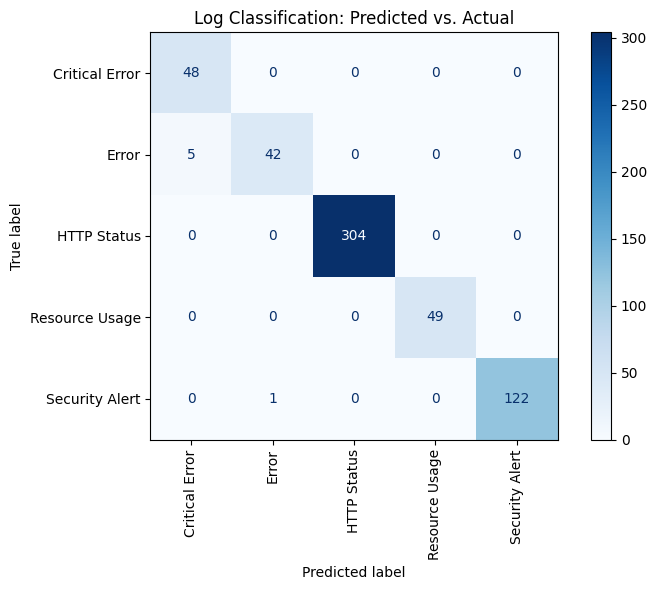

In [107]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Generate the raw matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Setup the display
# Use clf.classes_ to ensure labels match your model's categories
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)

# 3. Plot it
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)

# 4. Rotate the bottom (x-axis) labels 90 degrees
plt.xticks(rotation=90)

plt.title("Log Classification: Predicted vs. Actual")
plt.tight_layout() # Ensures the rotated labels aren't cut off at the bottom
plt.show()

In [108]:
print(f"Train Accuracy: {clf.score(X_train, y_train):.2f}")
print(f"Test Accuracy: {clf.score(X_test, y_test):.2f}")

Train Accuracy: 1.00
Test Accuracy: 0.99


In [102]:
# Saving the model
import joblib
joblib.dump(clf, '../models/log_classifier.joblib')

['../models/log_classifier.joblib']